# Bactomata // Plate Generator

In [1]:
import sys, os, random, time, shutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import ipywidgets as widgets
from IPython.display import display

import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
import random

from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

In [2]:
from google.colab import drive
drive.mount('/content/drive')

dirName='/content/drive/Shareddrives/ESB_Code/Bactomata/'
PROJECT_ROOT = Path(dirName)

os.chdir(PROJECT_ROOT)
print('Current directory:', Path.cwd())

pathOT='./bactomata/'
sys.path.append(pathOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current directory: /content/drive/Shareddrives/ESB_Code/Bactomata


In [3]:
import importlib
import bactomata.layout_widgets as blw

importlib.reload(blw)

<module 'bactomata.layout_widgets' from '/content/drive/Shareddrives/ESB_Code/Bactomata/bactomata/layout_widgets.py'>

## User-defined parameters

In [4]:

expeID='Bactomata_Example'

sample_vol=20
max_vol=200

num_cols=12
num_rows=8


In [5]:
num_plates = 2
same_media_layout_all_plates = False
same_bacteria_layout_all_plates = False

# Define Experiment Layouts


In [6]:
# Main experiment folder
EXPERIMENT_DIR = Path("experiments") / expeID

# Subfolders
LAYOUT_DIR = EXPERIMENT_DIR / "raw" / "layouts"
OT_SCRIPT_DIR = EXPERIMENT_DIR / "OT_scripts"

# Create folders if they do not exist
LAYOUT_DIR.mkdir(parents=True, exist_ok=True)
OT_SCRIPT_DIR.mkdir(parents=True, exist_ok=True)

# File names
scriptFile = f"{expeID}_script.py"

# Layout files
fileLayoutName = LAYOUT_DIR / f"{expeID}_media_layout.txt"
fileInoculationName = LAYOUT_DIR / f"{expeID}_bacteria_layout.txt"
fileTroughName = LAYOUT_DIR / f"{expeID}_trough_layout.txt"

# Key dictionaries
fileMediaKeyDictName = LAYOUT_DIR / f"{expeID}_media_key_dict.txt"
fileBacteriaKeyDictName = LAYOUT_DIR / f"{expeID}_bacteria_key_dict.txt"

# Legacy name used by OTScriptGenerator/DataLoader.
# For now, this points to the media key dictionary.
fileDictName = fileMediaKeyDictName

# Outfile: robot instructions
fileRobotName = OT_SCRIPT_DIR / scriptFile


In [7]:
params = blw.getParams(
    fileLayoutName=str(fileLayoutName),
    fileDictName=str(fileDictName),  # legacy: media key dictionary
    fileTroughName=str(fileTroughName),
    fileInoculationName=str(fileInoculationName),  # legacy name: bacteria layout
    fileRobotName=str(fileRobotName),
    max_vol=max_vol,
    num_rows=num_rows,
    num_cols=num_cols,
    num_plates=num_plates,
    sample_vol=sample_vol,
)

# New explicit paths used by Bactomata.
params["fileMediaKeyDictName"] = str(fileMediaKeyDictName)
params["fileBacteriaKeyDictName"] = str(fileBacteriaKeyDictName)


In [8]:
print("Media layout:        ", params["fileLayoutName"])
print("Bacteria layout:     ", params["fileInoculationName"])
print("Trough layout:       ", params["fileTroughName"])
print("Media key dict:      ", params["fileMediaKeyDictName"])
print("Bacteria key dict:   ", params["fileBacteriaKeyDictName"])
print("Legacy fileDictName: ", params["fileDictName"])
print("OT script:           ", params["fileRobotName"])


Media layout:         experiments/Bactomata_Example/raw/layouts/Bactomata_Example_media_layout.txt
Bacteria layout:      experiments/Bactomata_Example/raw/layouts/Bactomata_Example_bacteria_layout.txt
Trough layout:        experiments/Bactomata_Example/raw/layouts/Bactomata_Example_trough_layout.txt
Media key dict:       experiments/Bactomata_Example/raw/layouts/Bactomata_Example_media_key_dict.txt
Bacteria key dict:    experiments/Bactomata_Example/raw/layouts/Bactomata_Example_bacteria_key_dict.txt
Legacy fileDictName:  experiments/Bactomata_Example/raw/layouts/Bactomata_Example_media_key_dict.txt
OT script:            experiments/Bactomata_Example/OT_scripts/Bactomata_Example_script.py


### Trough Layout

In [9]:
trough_layout_inputs = blw.setup_trough_layout_inputs(
    params,
    nrows=3,
    ncols=4,
)

HTML(value='<b>Trough layout</b>')

GridBox(children=(HTML(value='', layout=Layout(width='28px')), HTML(value="<div style='text-align:center; font…

In [10]:
trough_layout_string, trough_unique_keys, trough_layout = blw.save_and_load_trough_layout(
    params,
    trough_layout_inputs,
)

### Plate Layout

In [11]:
media_layout_inputs = blw.setup_multiplate_layout_inputs(
    params=params,
    layout_file_key="fileLayoutName",
    num_plates=num_plates,
    same_layout_all_plates=same_media_layout_all_plates,
    nrows=8,
    ncols=12,
    title="Media layout",
)

HTML(value='<b>Media layout | plate 1</b>')

GridBox(children=(HTML(value='', layout=Layout(width='28px')), HTML(value="<div style='text-align:center; font…

HTML(value='<b>Media layout | plate 2</b>')

GridBox(children=(HTML(value='', layout=Layout(width='28px')), HTML(value="<div style='text-align:center; font…

In [12]:
M_all = blw.save_multiplate_layout_from_inputs(
    layout_inputs=media_layout_inputs,
    file_path=params["fileLayoutName"],
    num_plates=num_plates,
    same_layout_all_plates=same_media_layout_all_plates,
)

In [13]:
M_all[0]

[['M0', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M0'],
 ['M0', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M0'],
 ['M0', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M0'],
 ['M0', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M0'],
 ['M0', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M0'],
 ['M0', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M0'],
 ['M0', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M0'],
 ['M0', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M0']]

In [14]:
M_all[1]

[['M0', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M0'],
 ['M0', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M0'],
 ['M0', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M0'],
 ['M0', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M0'],
 ['M0', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M0'],
 ['M0', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M0'],
 ['M0', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M1', 'M0'],
 ['M0', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2', 'M2']]

### Media Key Dictionary


In [15]:
media_source_keys = sorted(trough_unique_keys)

print("Media source keys:", media_source_keys)

M_unique_keys, media_key_input_widgets = blw.setup_key_dict_inputs(
    layouts=M_all,
    source_keys=media_source_keys,
    key_dict_file=params["fileMediaKeyDictName"],
)

Media source keys: ['AMP', 'CHL', 'LB', 'OV1', 'OV2', 'OV3', 'OV4']


In [16]:
media_key_data = blw.save_key_dict_from_widgets(
    media_key_input_widgets,
    params["fileMediaKeyDictName"],
    source_keys=media_source_keys,
)

[{'KEY': 'M0', 'AMP': 0, 'CHL': 0, 'LB': 200, 'OV1': 0, 'OV2': 0, 'OV3': 0, 'OV4': 0}, {'KEY': 'M1', 'AMP': 0, 'CHL': 100, 'LB': 100, 'OV1': 0, 'OV2': 0, 'OV3': 0, 'OV4': 0}, {'KEY': 'M2', 'AMP': 100, 'CHL': 0, 'LB': 100, 'OV1': 0, 'OV2': 0, 'OV3': 0, 'OV4': 0}]

> Exporting experiments/Bactomata_Example/raw/layouts/Bactomata_Example_media_key_dict.txt


In [17]:
media_dict = blw.load_key_dict_from_file(
    params["fileMediaKeyDictName"]
)

media_cmap, media_source_keys, media_source_colors = blw.build_media_cmap(
    media_dict,
    empty_color="lightgray",
    cmap_name="tab10",
)

print("Media source keys:", media_source_keys)
print("Media source colors:", media_source_colors)
print("Media cmap:", media_cmap)

Media source keys: ['AMP', 'CHL', 'LB', 'OV1', 'OV2', 'OV3', 'OV4']
Media source colors: {'AMP': (np.float64(0.12156862745098039), np.float64(0.4666666666666667), np.float64(0.7058823529411765), np.float64(1.0)), 'CHL': (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0)), 'LB': (np.float64(0.17254901960784313), np.float64(0.6274509803921569), np.float64(0.17254901960784313), np.float64(1.0)), 'OV1': (np.float64(0.8392156862745098), np.float64(0.15294117647058825), np.float64(0.1568627450980392), np.float64(1.0)), 'OV2': (np.float64(0.5803921568627451), np.float64(0.403921568627451), np.float64(0.7411764705882353), np.float64(1.0)), 'OV3': (np.float64(0.5490196078431373), np.float64(0.33725490196078434), np.float64(0.29411764705882354), np.float64(1.0)), 'OV4': (np.float64(0.8901960784313725), np.float64(0.4666666666666667), np.float64(0.7607843137254902), np.float64(1.0))}
Media cmap: {'M0': (0.1725490196078432, 0.6274509803921569, 0.172



**** MEDIA LAYOUT | PLATE 1:



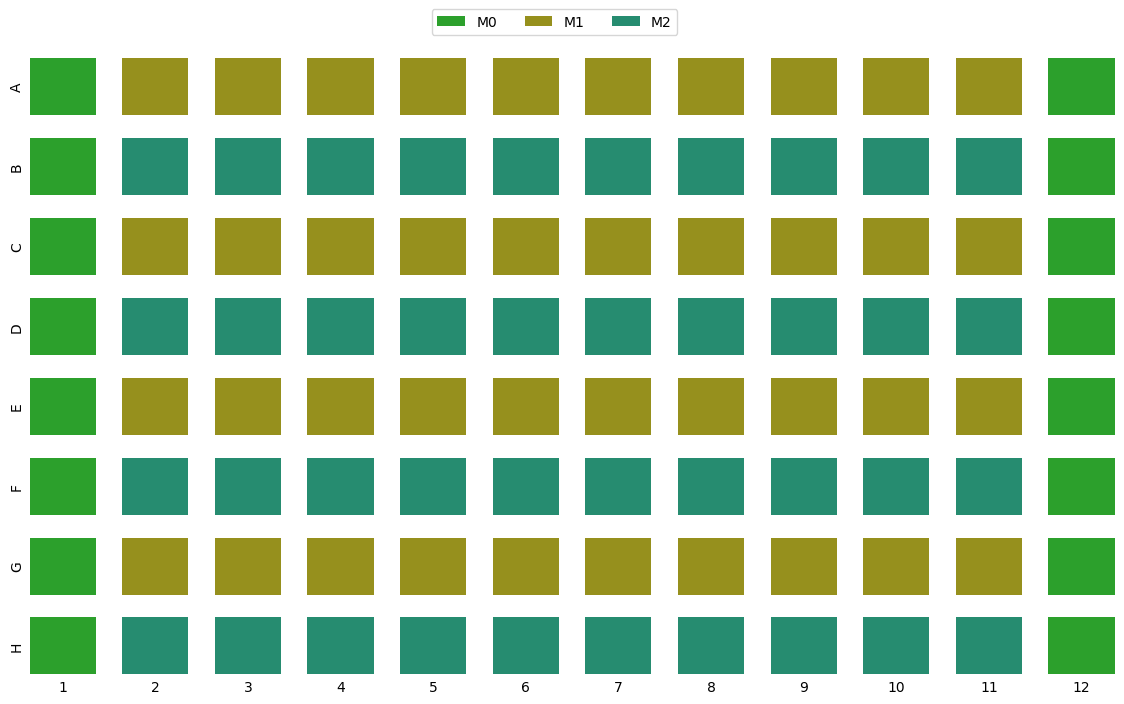



**** MEDIA LAYOUT | PLATE 2:



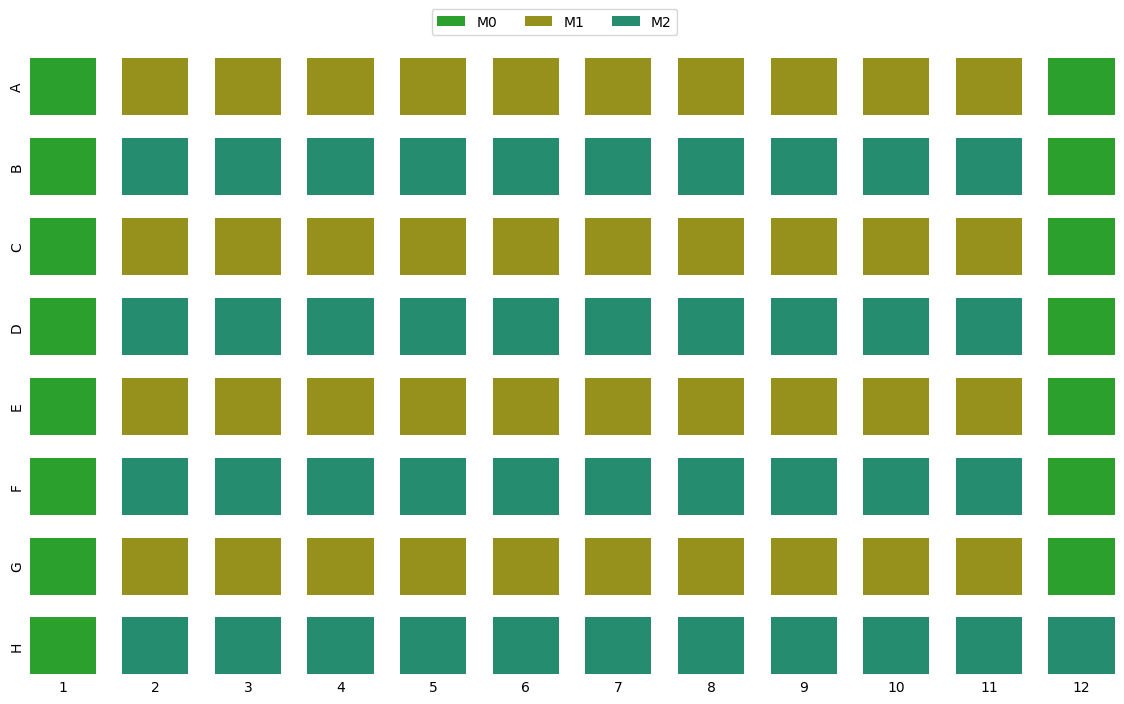

In [18]:
blw.plotHeatmapsFromLayouts(
    params,
    M_all,
    media_cmap,
    title="Media layout",
)

### Bacteria Layout


In [19]:
bacteria_layout_inputs = blw.setup_multiplate_layout_inputs(
    params=params,
    layout_file_key="fileInoculationName",
    num_plates=num_plates,
    same_layout_all_plates=same_bacteria_layout_all_plates,
    nrows=8,
    ncols=12,
    title="Bacteria layout",
)

HTML(value='<b>Bacteria layout | plate 1</b>')

GridBox(children=(HTML(value='', layout=Layout(width='28px')), HTML(value="<div style='text-align:center; font…

HTML(value='<b>Bacteria layout | plate 2</b>')

GridBox(children=(HTML(value='', layout=Layout(width='28px')), HTML(value="<div style='text-align:center; font…

In [20]:
B_all = blw.save_multiplate_layout_from_inputs(
    layout_inputs=bacteria_layout_inputs,
    file_path=params["fileInoculationName"],
    num_plates=num_plates,
    same_layout_all_plates=same_bacteria_layout_all_plates,
)

In [21]:
bacteria_cmap = blw.generate_bacteria_cmap(B_all, seed=1)

for key, color in bacteria_cmap.items():
    print(f"{key}: {color}")

# Compatibility with older plotting/script cells.
inoculation_cmap = bacteria_cmap

0: lightgray
B1: #442082
B2: #3cfde6
B3: #f1c26b
B4: #30f90e
MIX: #c7dd01


In [22]:
bacteria_source_keys = sorted(trough_unique_keys)

print("Bacteria source keys:", bacteria_source_keys)

B_unique_keys, bacteria_key_input_widgets = blw.setup_key_dict_inputs(
    layouts=B_all,
    source_keys=bacteria_source_keys,
    key_dict_file=params["fileBacteriaKeyDictName"],
)

Bacteria source keys: ['AMP', 'CHL', 'LB', 'OV1', 'OV2', 'OV3', 'OV4']


In [23]:
bacteria_key_data = blw.save_key_dict_from_widgets(
    bacteria_key_input_widgets,
    params["fileBacteriaKeyDictName"],
    source_keys=bacteria_source_keys,
)

[{'KEY': 'B1', 'AMP': 0, 'CHL': 0, 'LB': 0, 'OV1': 20, 'OV2': 0, 'OV3': 0, 'OV4': 0}, {'KEY': 'B2', 'AMP': 0, 'CHL': 0, 'LB': 0, 'OV1': 0, 'OV2': 20, 'OV3': 0, 'OV4': 0}, {'KEY': 'B3', 'AMP': 0, 'CHL': 0, 'LB': 0, 'OV1': 0, 'OV2': 0, 'OV3': 20, 'OV4': 0}, {'KEY': 'B4', 'AMP': 0, 'CHL': 0, 'LB': 0, 'OV1': 0, 'OV2': 0, 'OV3': 0, 'OV4': 20}, {'KEY': 'MIX', 'AMP': 0, 'CHL': 0, 'LB': 0, 'OV1': 5, 'OV2': 5, 'OV3': 5, 'OV4': 5}]

> Exporting experiments/Bactomata_Example/raw/layouts/Bactomata_Example_bacteria_key_dict.txt




**** BACTERIA LAYOUT | PLATE 1:



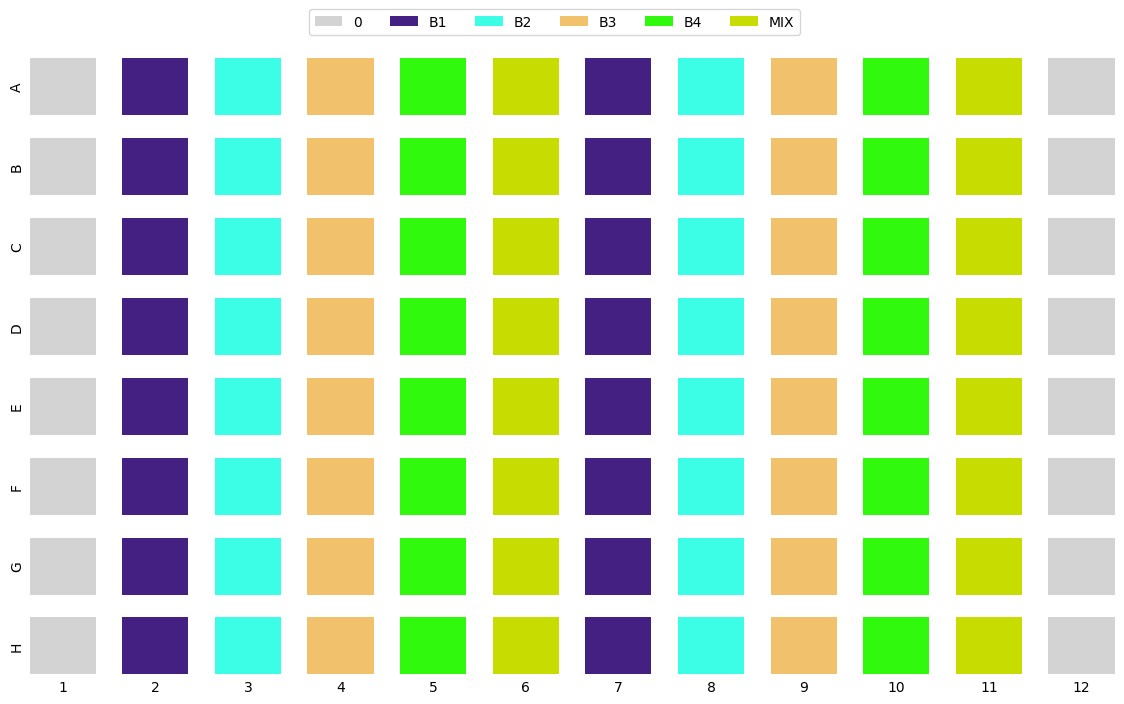



**** BACTERIA LAYOUT | PLATE 2:



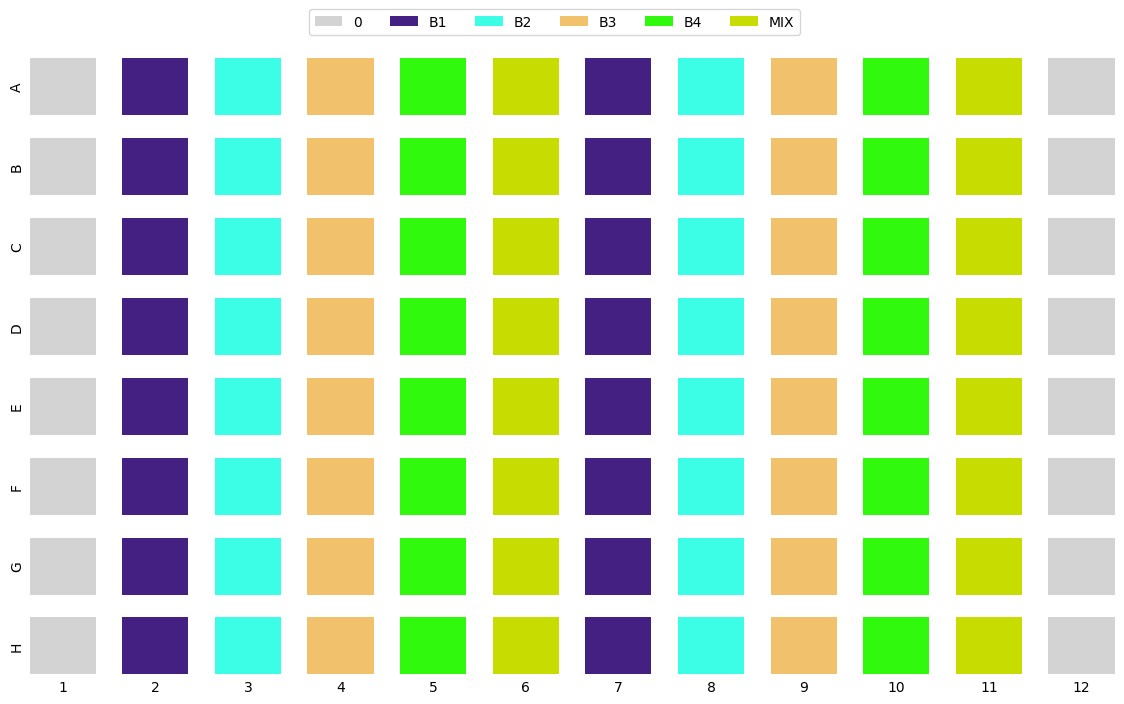

In [24]:
blw.plotHeatmapsFromLayouts(
    params,
    B_all,
    bacteria_cmap,
    title="Bacteria layout",
)